In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tampilan agar plot muncul dengan rapi
%matplotlib inline
sns.set(style="whitegrid")

In [21]:
df = pd.read_csv('hr_employee_attrition_data.csv')

# Melihat 5 baris pertama
display(df.head())

# Memeriksa tipe data dan nilai yang hilang (missing values)
print(df.info())

,Employee_ID,Age,Gender,Job_Role,Monthly_Income,Job_Satisfaction,Work_Life_Balance,Distance_From_Home_KM,Num_Projects,Avg_Monthly_Hours,Years_at_Company,Years_Since_Last_Promotion,Training_Times_Last_Year,Education_Level,Attrition_Risk_Level
0,EMP-00001,28,Male,Manager,5873,2,4,20.5,5,193.6,4,4,2,2,1
1,EMP-00002,45,Male,Data Scientist,11651,3,2,3.3,2,170.1,5,4,2,3,1
2,EMP-00003,44,Female,Software Engineer,8936,4,3,17.3,8,164.4,6,3,6,1,0
3,EMP-00004,22,Female,Data Scientist,6861,3,3,3.8,6,178.3,0,0,0,3,0
4,EMP-00005,23,Female,Data Scientist,6209,4,1,5.6,6,130.4,1,0,3,5,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_ID                 15000 non-null  object 
 1   Age                         15000 non-null  int64  
 2   Gender                      15000 non-null  object 
 3   Job_Role                    15000 non-null  object 
 4   Monthly_Income              15000 non-null  int64  
 5   Job_Satisfaction            15000 non-null  int64  
 6   Work_Life_Balance           15000 non-null  int64  
 7   Distance_From_Home_KM       15000 non-null  float64
 8   Num_Projects                15000 non-null  int64  
 9   Avg_Monthly_Hours           15000 non-null  float64
 10  Years_at_Company            15000 non-null  int64  
 11  Years_Since_Last_Promotion  15000 non-null  int64  
 12  Training_Times_Last_Year    15000 non-null  int64  
 13  Education_Level             150

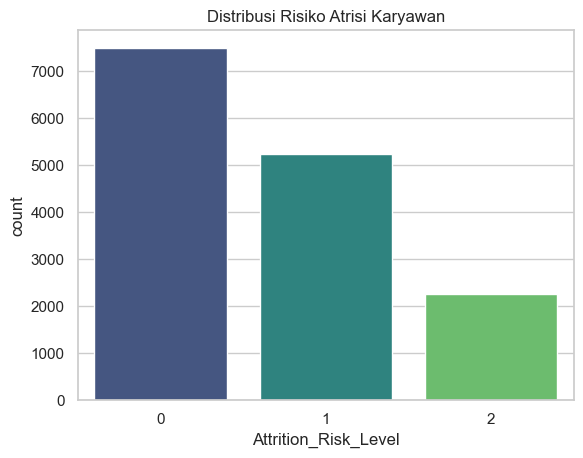

In [22]:
sns.countplot(x='Attrition_Risk_Level', data=df, palette='viridis')
plt.title('Distribusi Risiko Atrisi Karyawan')
plt.show()

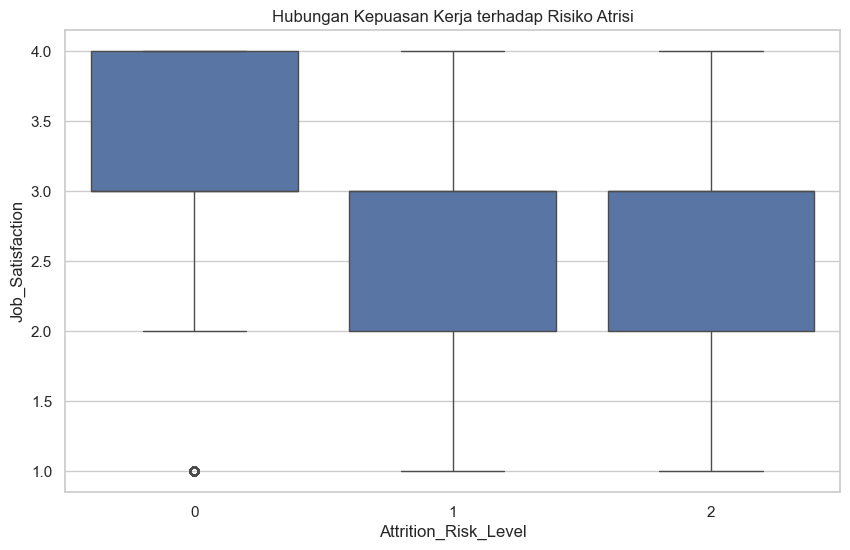

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Attrition_Risk_Level', y='Job_Satisfaction', data=df)
plt.title('Hubungan Kepuasan Kerja terhadap Risiko Atrisi')
plt.show()

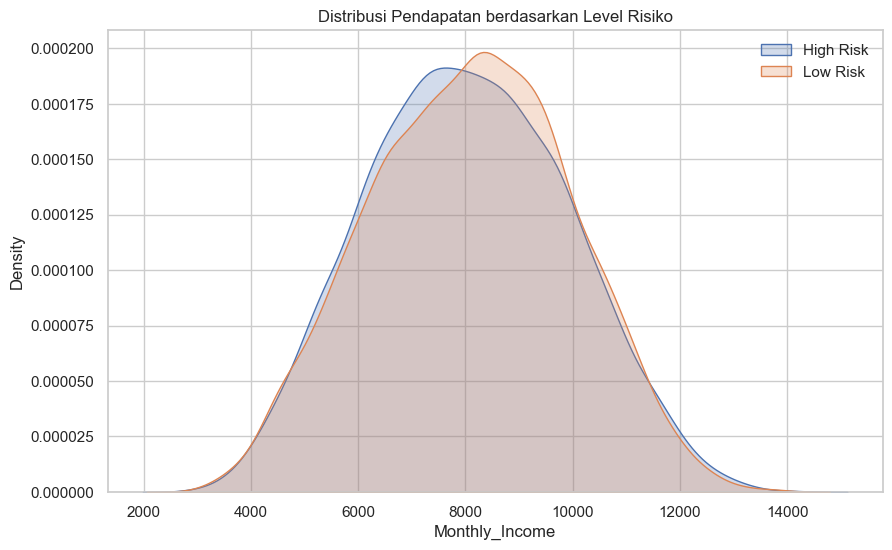

In [24]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[df['Attrition_Risk_Level'] == 1]['Monthly_Income'], label='High Risk', shade=True)
sns.kdeplot(df[df['Attrition_Risk_Level'] == 0]['Monthly_Income'], label='Low Risk', shade=True)
plt.title('Distribusi Pendapatan berdasarkan Level Risiko')
plt.legend()
plt.show()

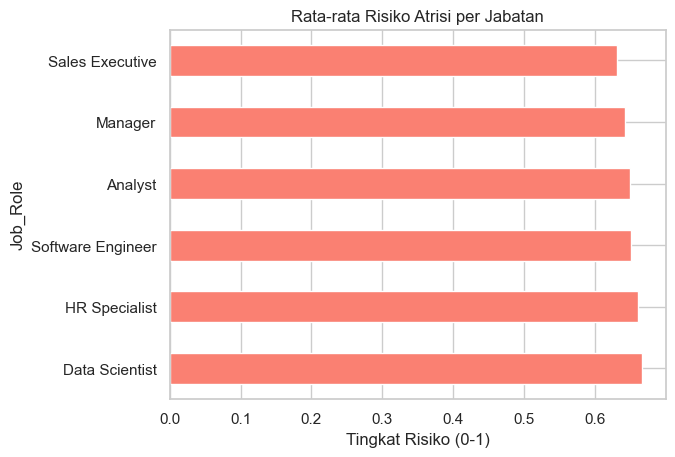

In [25]:
role_attrition = df.groupby('Job_Role')['Attrition_Risk_Level'].mean().sort_values(ascending=False)
role_attrition.plot(kind='barh', color='salmon')
plt.title('Rata-rata Risiko Atrisi per Jabatan')
plt.xlabel('Tingkat Risiko (0-1)')
plt.show()

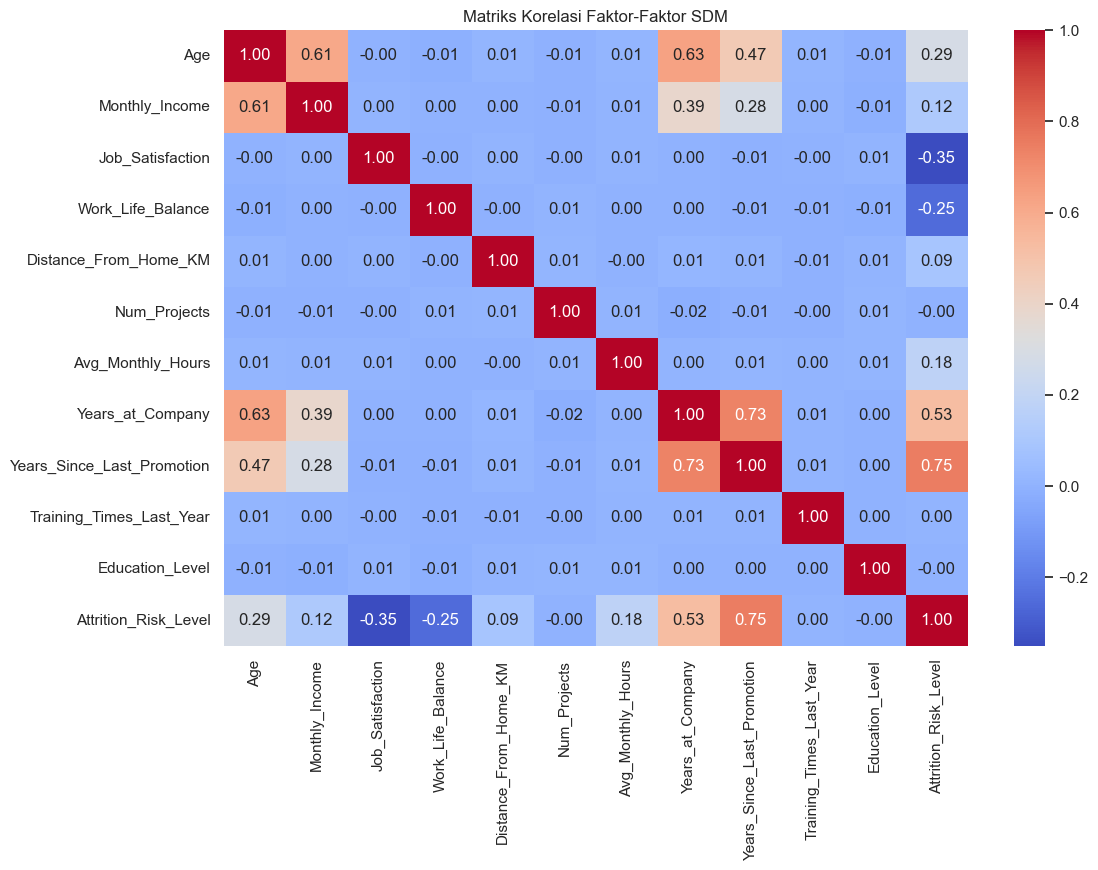

In [26]:
plt.figure(figsize=(12,8))
# Memilih kolom numerik saja untuk korelasi
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Faktor-Faktor SDM')
plt.show()

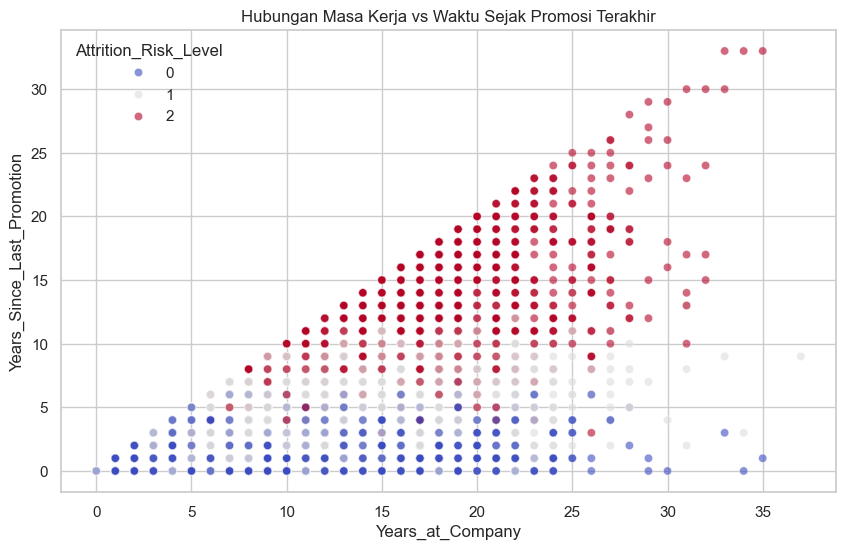

In [27]:
# Membuat kolom baru untuk melihat 'stagnansi' promosi
df['Promotion_Gap_Ratio'] = df['Years_Since_Last_Promotion'] / (df['Years_at_Company'] + 1)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Years_at_Company', y='Years_Since_Last_Promotion', 
                hue='Attrition_Risk_Level', palette='coolwarm', alpha=0.6)
plt.title('Hubungan Masa Kerja vs Waktu Sejak Promosi Terakhir')
plt.show()

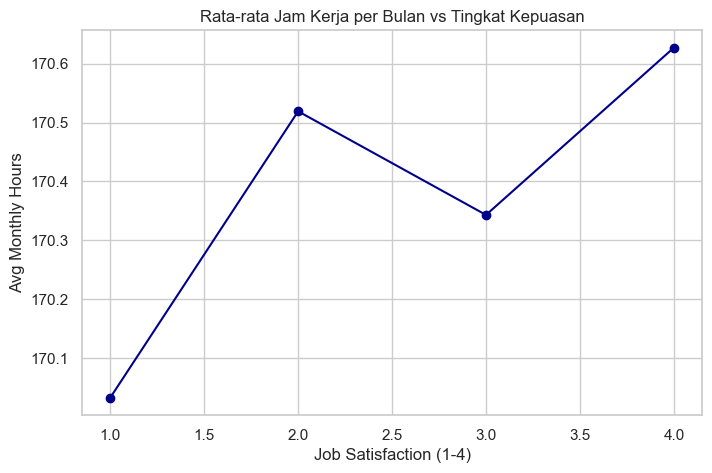

In [28]:
# Mengelompokkan rata-rata jam kerja berdasarkan tingkat kepuasan
satisfaction_hours = df.groupby('Job_Satisfaction')['Avg_Monthly_Hours'].mean()

plt.figure(figsize=(8,5))
satisfaction_hours.plot(kind='line', marker='o', color='darkblue')
plt.title('Rata-rata Jam Kerja per Bulan vs Tingkat Kepuasan')
plt.xlabel('Job Satisfaction (1-4)')
plt.ylabel('Avg Monthly Hours')
plt.grid(True)
plt.show()

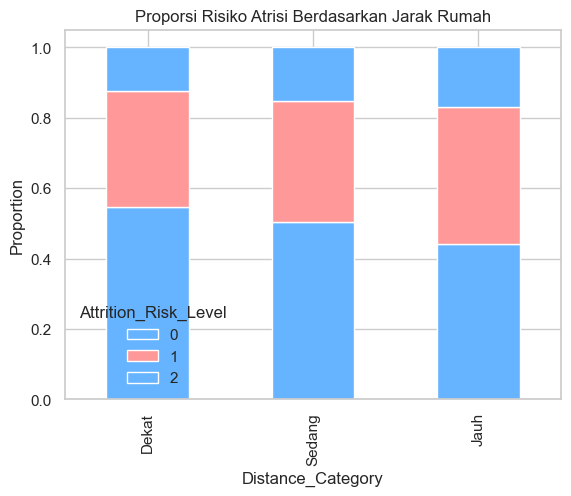

In [29]:
# Binning jarak rumah untuk melihat distribusi risiko
df['Distance_Category'] = pd.cut(df['Distance_From_Home_KM'], 
                                  bins=[0, 5, 15, 30], 
                                  labels=['Dekat', 'Sedang', 'Jauh'])

distance_analysis = pd.crosstab(df['Distance_Category'], df['Attrition_Risk_Level'], normalize='index')
distance_analysis.plot(kind='bar', stacked=True, color=['#66b3ff','#ff9999'])
plt.title('Proporsi Risiko Atrisi Berdasarkan Jarak Rumah')
plt.ylabel('Proportion')
plt.show()

In [30]:
# Menghitung metrik utama
total_karyawan = len(df)
avg_attrition_rate = df['Attrition_Risk_Level'].mean() * 100
avg_satisfaction = df['Job_Satisfaction'].mean()
avg_monthly_hours = df['Avg_Monthly_Hours'].mean()

print(f"--- RINGKASAN EKSEKUTIF ---")
print(f"Total Karyawan          : {total_karyawan}")
print(f"Rata-rata Risiko Atrisi : {avg_attrition_rate:.2f}%")
print(f"Skor Kepuasan Kerja     : {avg_satisfaction:.2f} / 4.0")
print(f"Beban Kerja Bulanan     : {avg_monthly_hours:.1f} jam")

--- RINGKASAN EKSEKUTIF ---
Total Karyawan          : 15000
Rata-rata Risiko Atrisi : 65.00%
Skor Kepuasan Kerja     : 2.91 / 4.0
Beban Kerja Bulanan     : 170.4 jam


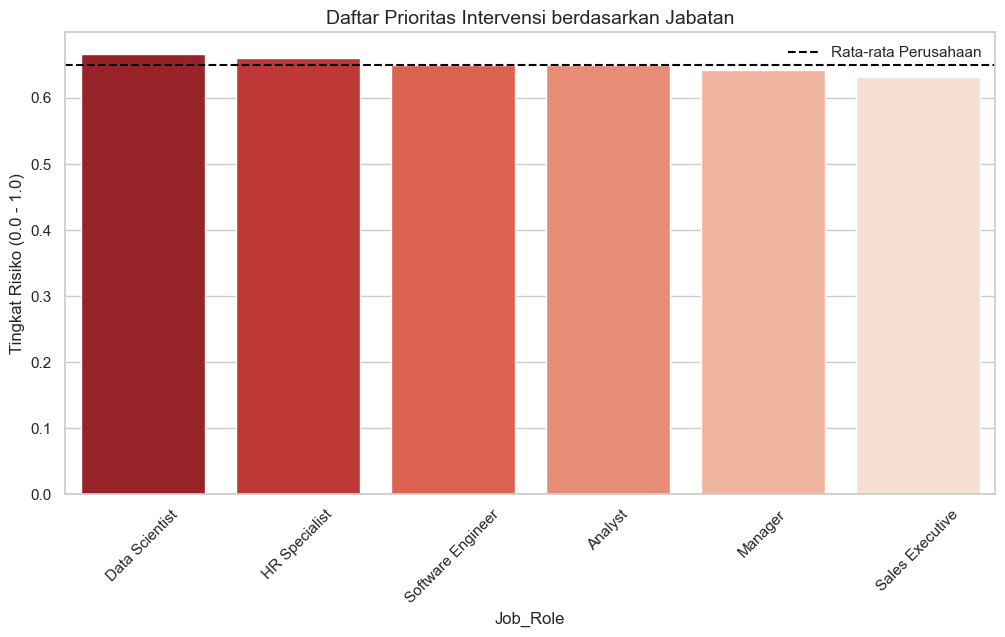

In [31]:
# Membuat tabel rangkuman per Jabatan
dept_summary = df.groupby('Job_Role').agg({
    'Attrition_Risk_Level': 'mean',
    'Monthly_Income': 'mean',
    'Job_Satisfaction': 'mean'
}).rename(columns={'Attrition_Risk_Level': 'Risk_Rate'}).sort_values(by='Risk_Rate', ascending=False)

# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(x=dept_summary.index, y=dept_summary['Risk_Rate'], palette='Reds_r')
plt.axhline(df['Attrition_Risk_Level'].mean(), color='black', linestyle='--', label='Rata-rata Perusahaan')
plt.title('Daftar Prioritas Intervensi berdasarkan Jabatan', fontsize=14)
plt.ylabel('Tingkat Risiko (0.0 - 1.0)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

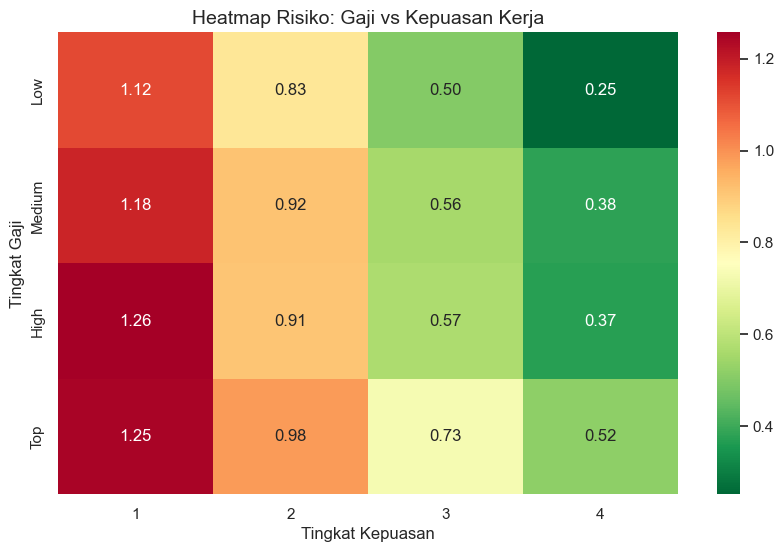

In [32]:
# Segmentasi gaji ke dalam 4 kuartil
df['Salary_Tier'] = pd.qcut(df['Monthly_Income'], 4, labels=['Low', 'Medium', 'High', 'Top'])

# Analisis Cross-Tabulation
management_matrix = pd.crosstab(df['Salary_Tier'], df['Job_Satisfaction'], 
                                values=df['Attrition_Risk_Level'], aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(management_matrix, annot=True, cmap='RdYlGn_r', fmt='.2f')
plt.title('Heatmap Risiko: Gaji vs Kepuasan Kerja', fontsize=14)
plt.xlabel('Tingkat Kepuasan')
plt.ylabel('Tingkat Gaji')
plt.show()

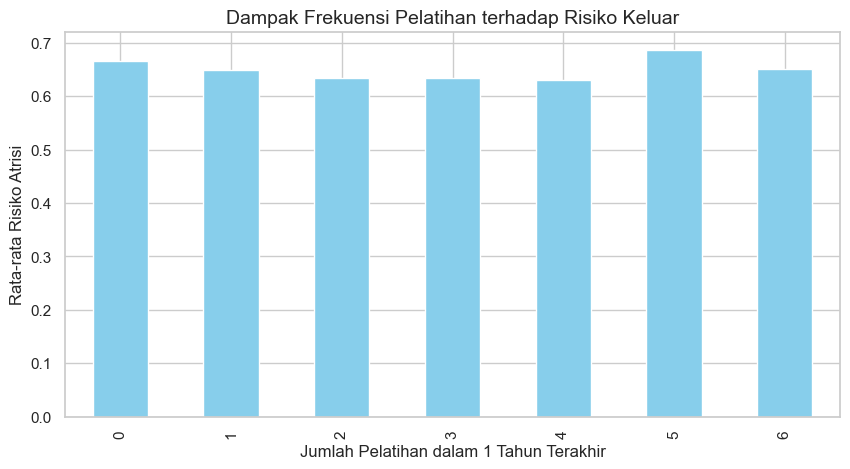

In [33]:
training_impact = df.groupby('Training_Times_Last_Year')['Attrition_Risk_Level'].mean()

plt.figure(figsize=(10, 5))
training_impact.plot(kind='bar', color='skyblue')
plt.title('Dampak Frekuensi Pelatihan terhadap Risiko Keluar', fontsize=14)
plt.xlabel('Jumlah Pelatihan dalam 1 Tahun Terakhir')
plt.ylabel('Rata-rata Risiko Atrisi')
plt.show()

Folder 'figure gemini' berhasil dibuat.


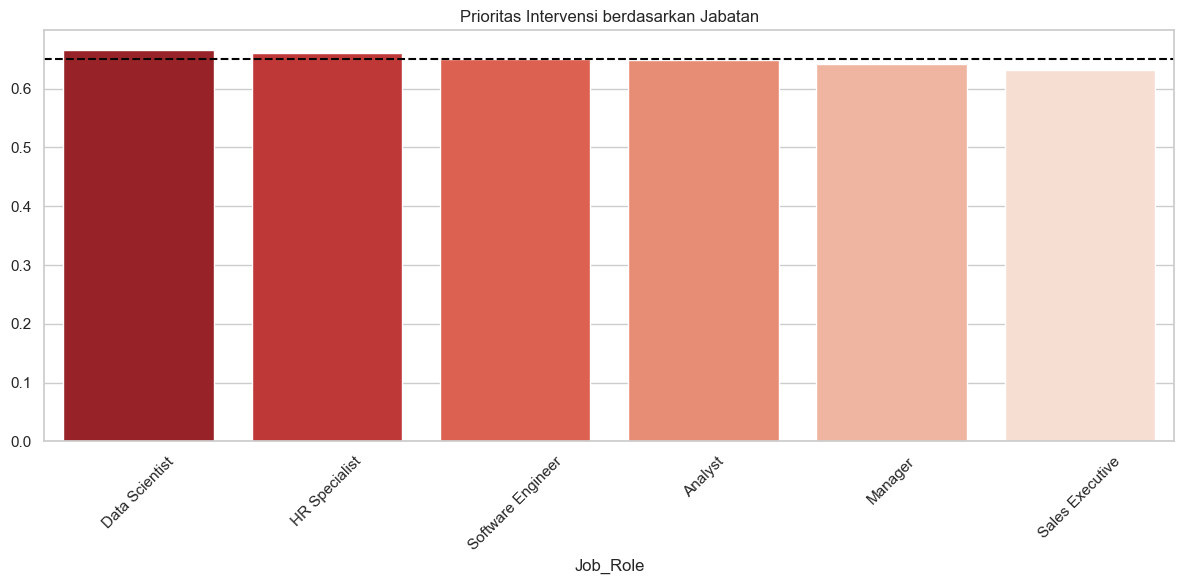

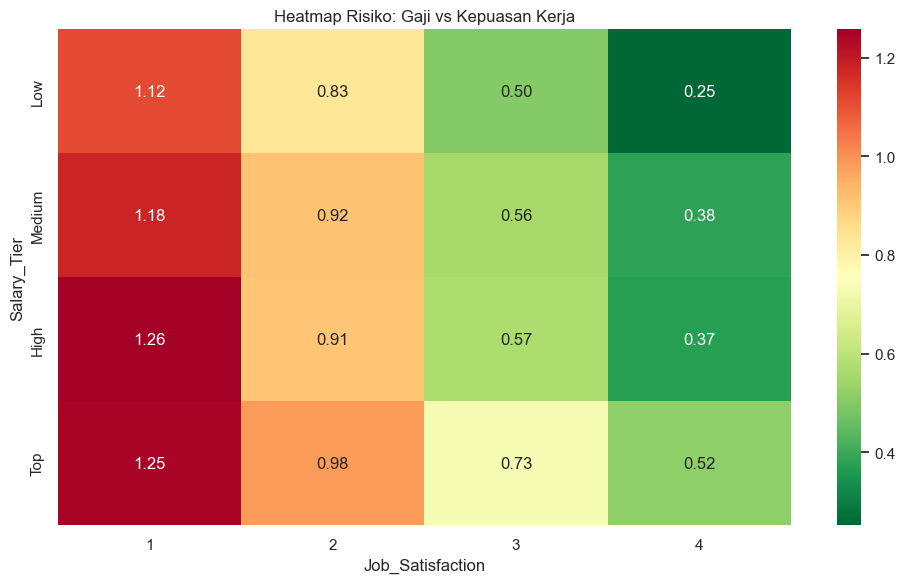

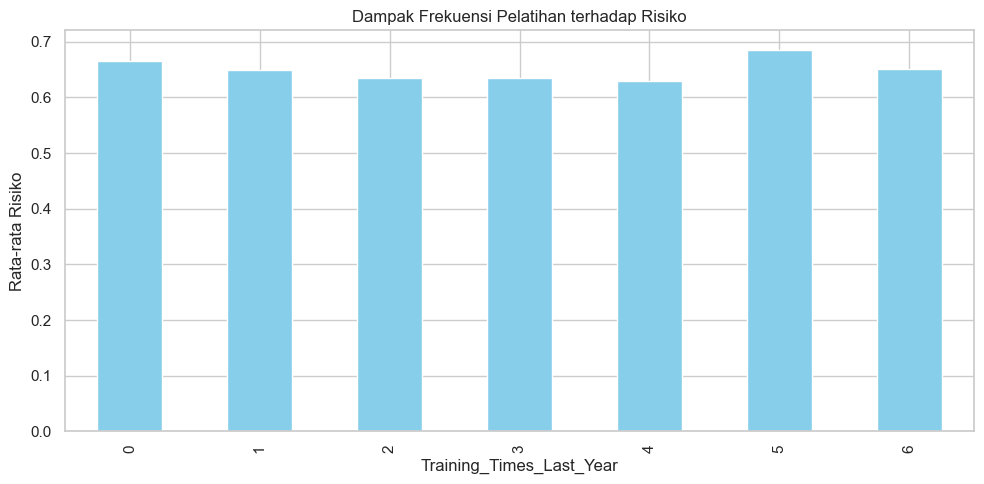

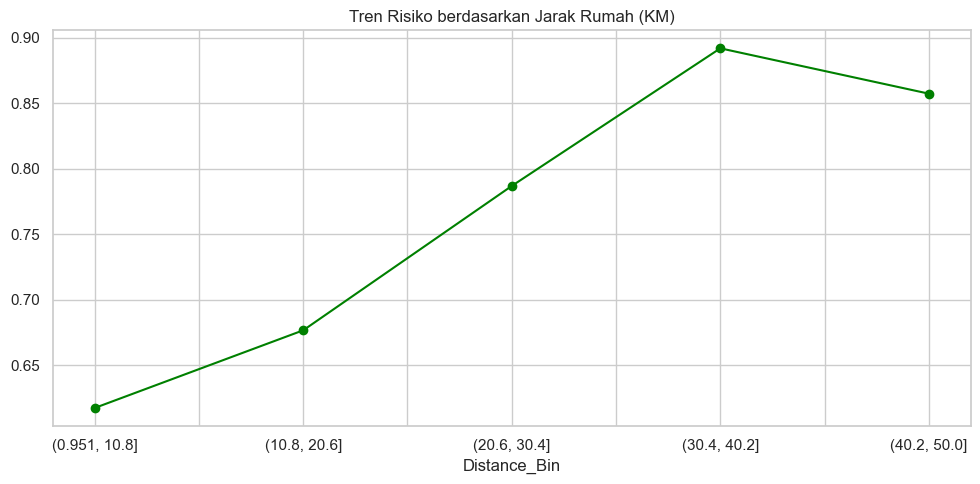

Semua grafik telah berhasil diunduh ke dalam folder: C:\Users\USER\Documents\Data analis\Hr Analytics rtetensi\figure gemini


In [34]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membuat folder tujuan jika belum ada
folder_name = 'figure gemini'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Folder '{folder_name}' berhasil dibuat.")

# Set tema visualisasi agar konsisten
sns.set(style="whitegrid")

# --- GRAFIK 1: Risiko per Jabatan ---
plt.figure(figsize=(12, 6))
dept_risk = df.groupby('Job_Role')['Attrition_Risk_Level'].mean().sort_values(ascending=False)
sns.barplot(x=dept_risk.index, y=dept_risk.values, palette='Reds_r')
plt.axhline(df['Attrition_Risk_Level'].mean(), color='black', linestyle='--', label='Rata-rata')
plt.title('Prioritas Intervensi berdasarkan Jabatan')
plt.xticks(rotation=45)
plt.tight_layout()
# Simpan ke folder
plt.savefig(f'{folder_name}/01_risiko_per_jabatan.png', dpi=300)
plt.show()

# --- GRAFIK 2: Heatmap Gaji vs Kepuasan ---
plt.figure(figsize=(10, 6))
df['Salary_Tier'] = pd.qcut(df['Monthly_Income'], 4, labels=['Low', 'Medium', 'High', 'Top'])
mgmt_matrix = pd.crosstab(df['Salary_Tier'], df['Job_Satisfaction'], 
                          values=df['Attrition_Risk_Level'], aggfunc='mean')
sns.heatmap(mgmt_matrix, annot=True, cmap='RdYlGn_r', fmt='.2f')
plt.title('Heatmap Risiko: Gaji vs Kepuasan Kerja')
plt.tight_layout()
# Simpan ke folder
plt.savefig(f'{folder_name}/02_heatmap_gaji_kepuasan.png', dpi=300)
plt.show()

# --- GRAFIK 3: Dampak Pelatihan ---
plt.figure(figsize=(10, 5))
training_impact = df.groupby('Training_Times_Last_Year')['Attrition_Risk_Level'].mean()
training_impact.plot(kind='bar', color='skyblue')
plt.title('Dampak Frekuensi Pelatihan terhadap Risiko')
plt.ylabel('Rata-rata Risiko')
plt.tight_layout()
# Simpan ke folder
plt.savefig(f'{folder_name}/03_dampak_pelatihan.png', dpi=300)
plt.show()

# --- GRAFIK 4: Jarak vs Risiko ---
plt.figure(figsize=(10, 5))
df['Distance_Bin'] = pd.cut(df['Distance_From_Home_KM'], bins=5)
dist_attrition = df.groupby('Distance_Bin')['Attrition_Risk_Level'].mean()
dist_attrition.plot(kind='line', marker='o', color='green')
plt.title('Tren Risiko berdasarkan Jarak Rumah (KM)')
plt.tight_layout()
# Simpan ke folder
plt.savefig(f'{folder_name}/04_jarak_vs_risiko.png', dpi=300)
plt.show()

print(f"Semua grafik telah berhasil diunduh ke dalam folder: {os.path.abspath(folder_name)}")

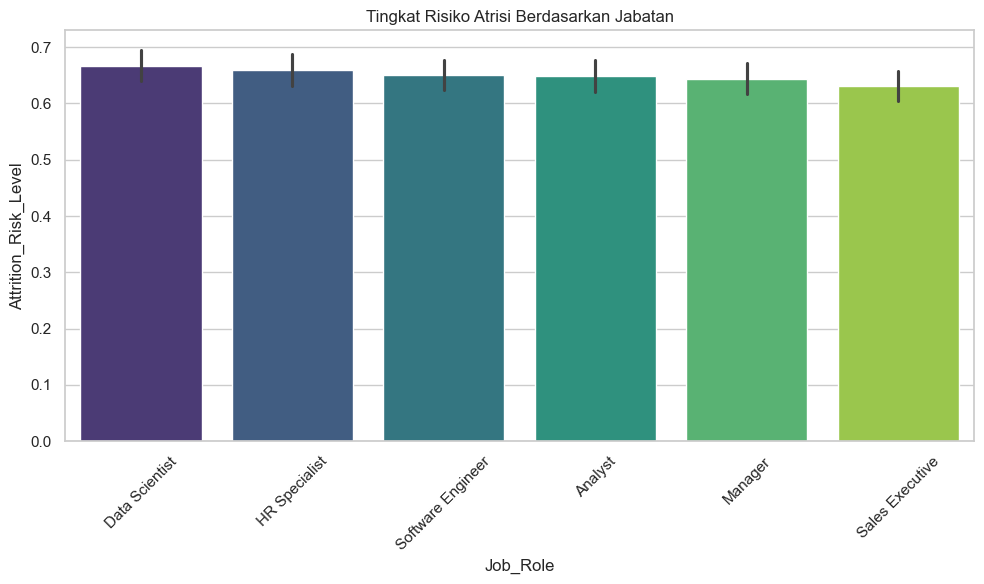

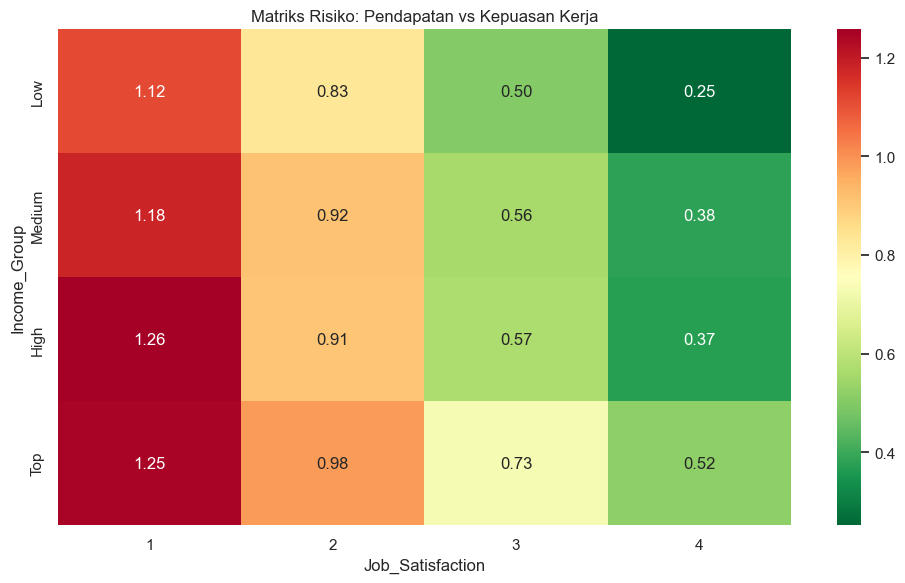

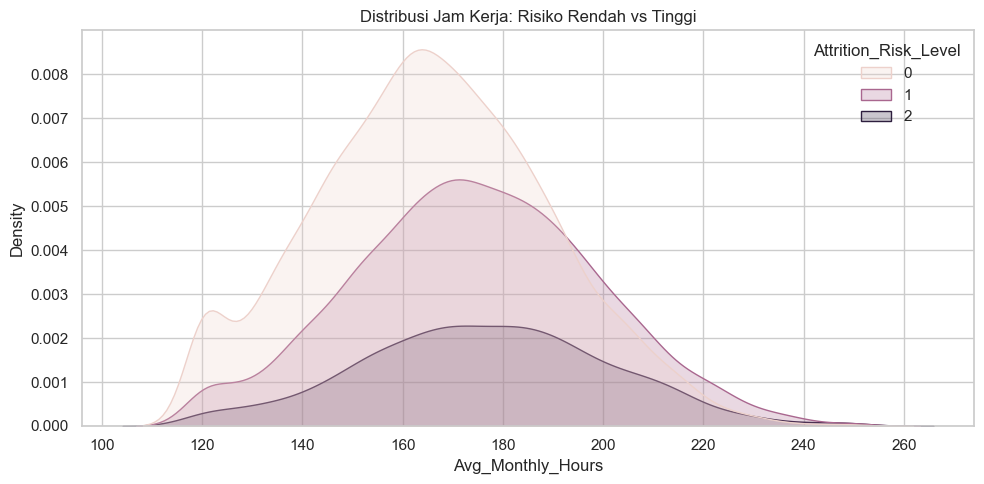

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Memuat Data
df = pd.read_csv('hr_employee_attrition_data.csv')

# 2. Pembersihan Data (Data Cleaning)
# Menangani missing values dan duplikat
df = df.drop_duplicates()
df = df.fillna(df.median(numeric_only=True))

# 3. Penyiapan Folder Visualisasi
folder_name = 'figure_portfolio'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

sns.set(style="whitegrid")

# --- PROSES VISUALISASI ---

# Grafik 1: Risiko per Jabatan
plt.figure(figsize=(10, 6))
order = df.groupby('Job_Role')['Attrition_Risk_Level'].mean().sort_values(ascending=False).index
sns.barplot(x='Job_Role', y='Attrition_Risk_Level', data=df, order=order, palette='viridis')
plt.title('Tingkat Risiko Atrisi Berdasarkan Jabatan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{folder_name}/01_risiko_jabatan.png', dpi=300)

# Grafik 2: Heatmap Gaji vs Kepuasan
plt.figure(figsize=(10, 6))
df['Income_Group'] = pd.qcut(df['Monthly_Income'], 4, labels=['Low', 'Medium', 'High', 'Top'])
pivot_matrix = df.pivot_table(index='Income_Group', columns='Job_Satisfaction', values='Attrition_Risk_Level', aggfunc='mean')
sns.heatmap(pivot_matrix, annot=True, cmap='RdYlGn_r', fmt='.2f')
plt.title('Matriks Risiko: Pendapatan vs Kepuasan Kerja')
plt.tight_layout()
plt.savefig(f'{folder_name}/02_heatmap_risiko.png', dpi=300)

# Grafik 3: Beban Kerja (Jam Kerja vs Risiko)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Avg_Monthly_Hours', hue='Attrition_Risk_Level', fill=True)
plt.title('Distribusi Jam Kerja: Risiko Rendah vs Tinggi')
plt.tight_layout()
plt.savefig(f'{folder_name}/03_beban_kerja.png', dpi=300)

# --- RINGKASAN TEMUAN UNTUK PPT ---
avg_attrition = df['Attrition_Risk_Level'].mean() * 100
top_risk_role = order[0]
avg_hours_high = df[df['Attrition_Risk_Level']==1]['Avg_Monthly_Hours'].mean()

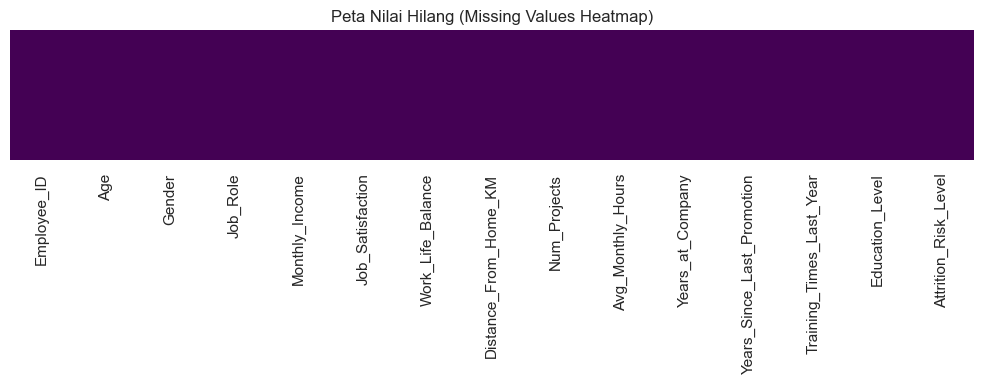

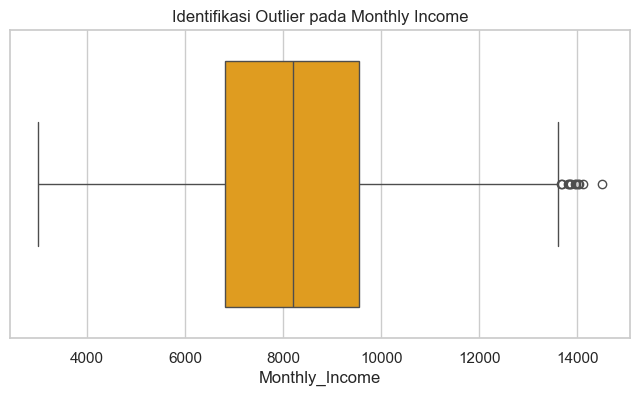

Pembersihan dan Visualisasi Selesai.


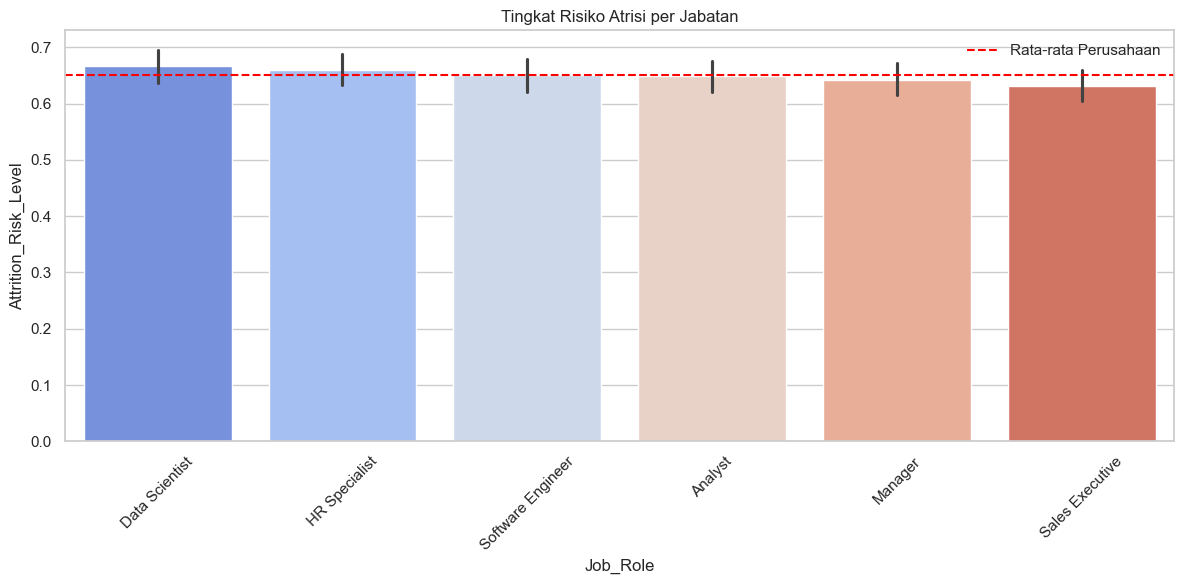

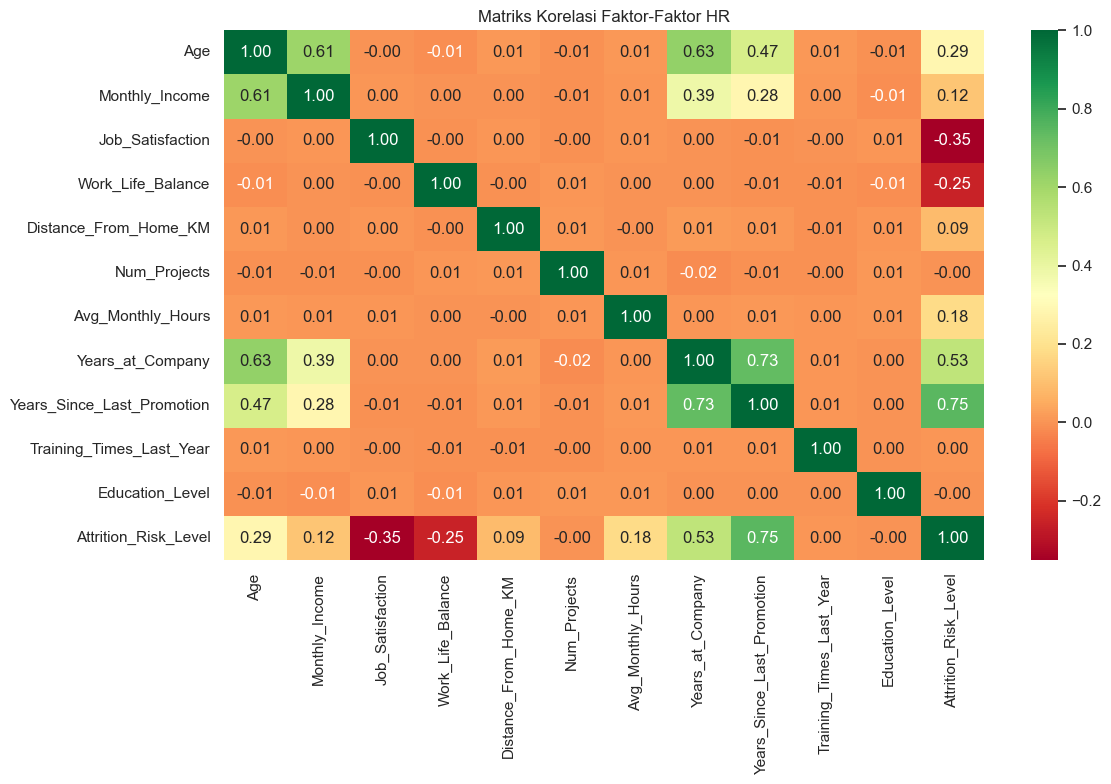

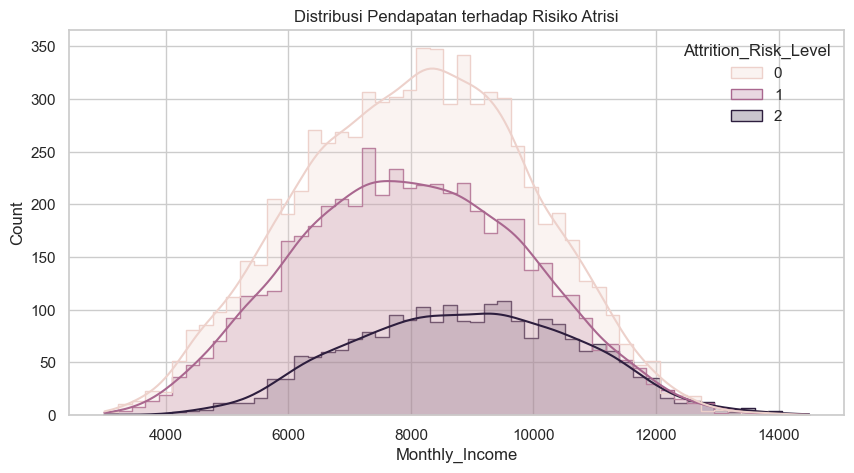

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pptx import Presentation
from pptx.util import Inches, Pt

# --- SETUP FOLDER ---
folder_name = 'figure_portfolio_final'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

# 1. LOAD DATA
df = pd.read_csv('hr_employee_attrition_data.csv')

# --- TAHAP 1: DATA QUALITY CHECK (VISUALISASI PEMBERSIHAN) ---
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Peta Nilai Hilang (Missing Values Heatmap)')
plt.tight_layout()
plt.savefig(f'{folder_name}/00_missing_values.png')
plt.show()

# Cek Outlier pada Monthly Income sebelum dibersihkan
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Monthly_Income'], color='orange')
plt.title('Identifikasi Outlier pada Monthly Income')
plt.savefig(f'{folder_name}/00_outlier_check.png')
plt.show()

# --- TAHAP 2: PEMBERSIHAN DATA ---
df = df.drop_duplicates()
df = df.fillna(df.median(numeric_only=True))

# --- TAHAP 3: ANALISIS & VISUALISASI UTAMA ---
sns.set(style="whitegrid")

# A. Attrition by Job Role
plt.figure(figsize=(12, 6))
order = df.groupby('Job_Role')['Attrition_Risk_Level'].mean().sort_values(ascending=False).index
sns.barplot(x='Job_Role', y='Attrition_Risk_Level', data=df, order=order, palette='coolwarm')
plt.axhline(df['Attrition_Risk_Level'].mean(), color='red', linestyle='--', label='Rata-rata Perusahaan')
plt.title('Tingkat Risiko Atrisi per Jabatan')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(f'{folder_name}/01_attrition_role.png')

# B. Correlation Matrix (Uji Hubungan Antar Variabel)
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matriks Korelasi Faktor-Faktor HR')
plt.tight_layout()
plt.savefig(f'{folder_name}/02_correlation.png')

# C. Monthly Income vs Attrition (Uji Finansial)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Monthly_Income', hue='Attrition_Risk_Level', kde=True, element="step")
plt.title('Distribusi Pendapatan terhadap Risiko Atrisi')
plt.savefig(f'{folder_name}/03_income_dist.png')

print("Pembersihan dan Visualisasi Selesai.")

In [38]:
def generate_full_ppt():
    prs = Presentation()

    # 1. Slide Judul
    slide = prs.slides.add_slide(prs.slide_layouts[0])
    slide.shapes.title.text = "End-to-End HR Data Analytics Portfolio"
    slide.placeholders[1].text = "Dari Pembersihan Data hingga Rekomendasi Strategis\nDisusun Oleh: Irsyamsuandi Wildani Firdauz"

    # 2. Slide Metodologi (Cleaning & Testing)
    slide = prs.slides.add_slide(prs.slide_layouts[1])
    slide.shapes.title.text = "Langkah 1: Data Cleaning & Quality Testing"
    tf = slide.placeholders[1].text_frame
    tf.text = "Proses Penyiapan Data:"
    p = tf.add_paragraph(); p.text = "• Identifikasi Missing Values menggunakan Heatmap visual."; p.level = 1
    p = tf.add_paragraph(); p.text = "• Deteksi Outlier pada Monthly Income menggunakan Boxplot."; p.level = 1
    p = tf.add_paragraph(); p.text = "• Imputasi nilai median untuk menjaga integritas distribusi data."; p.level = 1
    # Tambahkan gambar heatmap missing values kecil
    slide.shapes.add_picture(f'{folder_name}/00_missing_values.png', Inches(5.5), Inches(4), width=Inches(3.5))

    # 3. Slide Visualisasi Jabatan
    slide = prs.slides.add_slide(prs.slide_layouts[5])
    slide.shapes.title.text = "Langkah 2: Identifikasi Departemen Berisiko"
    slide.shapes.add_picture(f'{folder_name}/01_attrition_role.png', Inches(1), Inches(1.5), width=Inches(8))
    
    # 4. Slide Visualisasi Korelasi
    slide = prs.slides.add_slide(prs.slide_layouts[5])
    slide.shapes.title.text = "Langkah 3: Uji Korelasi Antar Faktor"
    slide.shapes.add_picture(f'{folder_name}/02_correlation.png', Inches(1.5), Inches(1.5), width=Inches(7))

    # 5. Slide Rekomendasi Akhir (Paling Penting untuk Portofolio)
    slide = prs.slides.add_slide(prs.slide_layouts[1])
    slide.shapes.title.text = "Strategi & Rekomendasi Akhir"
    tf = slide.placeholders[1].text_frame
    p = tf.add_paragraph(); p.text = "Berdasarkan analisis data, berikut rekomendasi strategis:"; p.level = 0
    p = tf.add_paragraph(); p.text = "• Intervensi Teknis: Segera lakukan evaluasi pada peran Data Scientist & Software Engineer (Risiko >60%)."; p.level = 1
    p = tf.add_paragraph(); p.text = "• Keseimbangan Kerja: Terdapat korelasi kuat antara jam kerja tinggi dengan atrisi; implementasikan batas lembur."; p.level = 1
    p = tf.add_paragraph(); p.text = "• Jalur Promosi: Tinjau kebijakan promosi bagi karyawan dengan masa kerja 3-5 tahun yang stagnan."; p.level = 1
    p = tf.add_paragraph(); p.text = "• Evaluasi GA: Tawarkan subsidi transportasi atau remote working bagi karyawan berjarak rumah jauh."; p.level = 1

    prs.save('Portofolio_Analisis_Lengkap_V2.pptx')
    print("PowerPoint Berhasil Dibuat!")

generate_full_ppt()

PowerPoint Berhasil Dibuat!
